In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import sys
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P/behavior',
                 '/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P/utilities'])
from animal import animal
from scipy.stats import zscore
import numpy as np
import seaborn as sb
from matplotlib import rcParams
import os
import pandas as pd
import pingouin as pg
plt.style.use('paper_style.mplstyle')

# Helper functions

In [ ]:
def interval_indices(timestamps, starts, stops):
    """
    timestamps: (N,) array
    starts, stops: (K,) arrays, same units as timestamps
    """
    timestamps = np.asarray(timestamps)
    starts = np.asarray(starts)
    stops = np.asarray(stops)

    out = []
    for s, e in zip(starts, stops):
        mask = (timestamps >= s) & (timestamps <= e)
        out.append(np.flatnonzero(mask))
    return out

def make_trial_table(cs1_starts, cs1_stops, cs2_starts=None, cs2_stops=None):
    cs1 = pd.DataFrame({
        "type": "cs1",
        "type_trial": np.arange(len(cs1_starts), dtype=int),
        "start": cs1_starts,
        "stop": cs1_stops})
    
    if cs2_starts is not None:
        cs2 = pd.DataFrame({
            "type": "cs2",
            "type_trial": np.arange(len(cs2_starts), dtype=int),
            "start": cs2_starts,
            "stop": cs2_stops,
        })

        trials = pd.concat([cs1, cs2], ignore_index=True).sort_values("start").reset_index(drop=True)
        trials["trial"] = np.arange(len(trials), dtype=int)  # global trial number in sorted order
    else:
        trials = cs1.copy()
        trials["trial"] = np.arange(len(trials), dtype=int)  # global trial number in sorted order

    return trials[["trial", "type", "type_trial", "start", "stop"]]



In [3]:
base_dir = '/Users/amonast/Desktop/Tone2P'
file_key = f"{base_dir}/Data_info_TFC.csv"


In [6]:
fr=30
animals = ['997B', '639N', 'M1N', 'M2L','M5L','M8BL2', 
           'M9BR2', 'F5L', 'F7N', 'F2R', '194L','939L']
ani_dfs=[]
all_trials=[]
for ani in animals:
    session = 'Recall1'
    mouse = animal(ani,'FOV1',file_key,base_dir)
    traces_df = mouse.load_traces(signal='events',sessions=[session])
    timestamps = traces_df['timestamps']
    
    df1 = mouse.load_position_df(session)
    Vt= mouse.compute_velocity(sessions=[session],window_size=30,threshold=1)
    Vt_Z = zscore(Vt)
    # tone_data:
    cs1_starts, cs1_stops= mouse.load_tone_times(session_name=session)
    cs1_inds = interval_indices(timestamps, cs1_starts, cs1_stops)
    # 20 seconds before each CS
    pre_starts = cs1_starts - 20
    pre_stops  = cs1_starts
    pre_inds   = interval_indices(timestamps, pre_starts, pre_stops)

    trials = make_trial_table(cs1_starts, cs1_stops)
    trials['Animal']=ani
    all_trials.append(trials)
    
    stim_blocks = [("Pre-CS", pre_starts, pre_stops, pre_inds),
                   ("CS1",    cs1_starts, cs1_stops, cs1_inds),]

    for stim_name, starts, stops,cs_inds in stim_blocks:
        for i, (t_start, t_stop,inds) in enumerate(zip(starts, stops,cs_inds), start=1):
        # trial number for the i-th CS1 (works for both Pre-CS and CS1)
            trial_num = trials.loc[(trials["type"] == "cs1") & (trials["type_trial"] == (i - 1)),"trial"].iloc[0]            
            v_trial = Vt[inds].mean()
            v_trial_z = Vt_Z[inds].mean()
            df=pd.DataFrame()
            df['Velocity']=[v_trial]
            df['Velocity_Zscore']=[v_trial_z]
            df['Trial']=[trial_num]
            df['CS-trial']=[i]
            df['Period']=stim_name
            df['Animal']=ani
            ani_dfs.append(df)
    vel_df=pd.concat(ani_dfs,ignore_index=True)

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_40794/2546590049.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data,
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_40794/2546590049.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.stripplot(data=data,
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


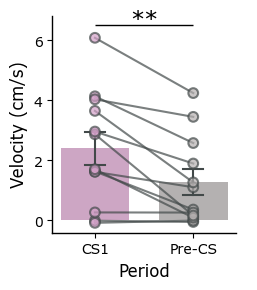

In [ ]:
data = vel_df.groupby(['Animal','Period']).mean().reset_index()
rcParams['axes.linewidth'] = 1. # set the value globally

plt.figure(figsize=(2.7,3))
gray='#424949'
colors = colors = ['#d3a0c8','#B5B0B0']
# Plot the barplot
sb.barplot(data=data,
           x='Period', y='Velocity', 
           palette=colors, 
           width=.7, linewidth=1.5, 
           edgecolor=None, 
           err_kws={'color': gray,'lw':1.5}, 
           errorbar='se', capsize=.2)

# Overlay individual points (strip plot)
sb.stripplot(data=data,
           x='Period', y='Velocity', 
           palette=colors, 
            edgecolor=gray, 
            linewidth=1.5, 
            dodge=None,
            jitter=0, 
            alpha=.7, 
            size=7,
            legend=False)

# Add lines connecting "engram" and "non-engram" for each animal
for i, ani in enumerate(data['Animal'].unique()):
    animal_data = data[data['Animal'] == ani]
    
    x1,x2=0,1
    CS1_data = animal_data[(animal_data['Period'] == 'CS1') ]
    CS2_data = animal_data[(animal_data['Period'] == 'Pre-CS') ]
    
    plt.plot([x1, x2], 
                [CS1_data['Velocity'].values[0],
                            CS2_data['Velocity'].values[0],], 
                color=gray, linewidth=1.5, alpha=0.7)

# Draw horizontal lines and annotations
plt.hlines(6.5,0,1,linewidth=1,color='k')
plt.text(.5,6.5,'**',ha='center',size=16)

# Add the legend and format axes
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), frameon=False)
#plt.ylim(0,3)
plt.ylabel('Velocity (cm/s)')

# Clean up plot
sb.despine()
plt.legend(bbox_to_anchor=(1.1,1),frameon=False)
plt.tight_layout()
plt.savefig('Fig5C_mean_velocity_bar.svg',transparent=True)

In [49]:
mean_all_ani=vel_df.groupby(['Animal','Period']).mean().reset_index()
pre= mean_all_ani.Velocity.loc[mean_all_ani['Period']=='Pre-CS']
tone=mean_all_ani.Velocity.loc[mean_all_ani['Period']=='CS1']
pg.normality(mean_all_ani,group='Period',dv='Velocity')

,W,pval,normal
Period,,,
CS1,0.946441,0.585681,True
Pre-CS,0.850048,0.036763,False


In [52]:
pg.wilcoxon(pre,tone)

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,3.0,two-sided,0.002441,-0.923077,0.340278


/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_40794/35143804.py:54: RuntimeWarning: Mean of empty slice
  vbar = np.nanmean(trials_mat, axis=0)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_40794/35143804.py:54: RuntimeWarning: Mean of empty slice
  vbar = np.nanmean(trials_mat, axis=0)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_40794/35143804.py:54: RuntimeWarning: Mean of empty slice
  vbar = np.nanmean(trials_mat, axis=0)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_40794/35143804.py:54: RuntimeWarning: Mean of empty slice
  vbar = np.nanmean(trials_mat, axis=0)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_40794/35143804.py:54: RuntimeWarning: Mean of empty slice
  vbar = np.nanmean(trials_mat, axis=0)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_40794/35143804.py:54: RuntimeWarning: Mean of empty slice
  vbar = np.nanmean(trials_mat, axis=0)
/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel

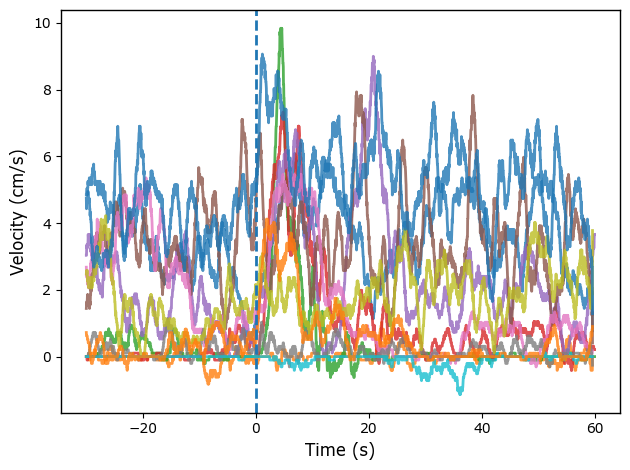

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def pad_1d(arr, target_len, pad_value=np.nan):
    """Pad/truncate a 1D array to target_len."""
    arr = np.asarray(arr)
    if arr.size >= target_len:
        return arr[:target_len]
    out = np.full(target_len, pad_value, dtype=float)
    out[:arr.size] = arr
    return out

seconds_pre = 30
seconds_post = 60
session = "Recall1"
fs = 30  # samples/sec (your code uses /30 everywhere)

# window length in samples, inclusive of 0 if you want; here it's exact duration
n_pre = int(seconds_pre * fs)
n_post = int(seconds_post * fs)
win_len = n_pre + n_post  # total samples in window

plt.figure()

DF = []          # collect per-animal long-form dfs here
mean_vs = []     # per-animal mean trace (win_len,)
v_animal = []    # per-animal trial x time arrays

for ani in animals:
    mouse = animal(ani, "FOV1", file_key, base_dir)

    # timestamps exist if you need trial indexing in trace-time
    traces_df = mouse.load_traces(signal="events", sessions=[session])
    timestamps = np.asarray(traces_df["timestamps"])

    # velocity trace (assumed aligned to timestamps / same sampling)
    Vt = np.asarray(mouse.compute_velocity(sessions=[session], window_size=30, threshold=1))
    Vt_Z = zscore(Vt)

    # tone windows -> indices into timestamps (your existing approach)
    cs1_starts, cs1_stops = mouse.load_tone_times(session_name=session)
    trial_inds = interval_indices(timestamps, cs1_starts-seconds_pre, cs1_starts+seconds_post)

    n_trials = 10

    # build trial x time matrix, padding to the analysis window length
    trials_mat = np.vstack([pad_1d(Vt[trial_inds[t]], win_len, pad_value=np.nan)
                            for t in range(n_trials)])

    v_animal.append(trials_mat)

    # mean across trials, ignoring padded NaNs
    vbar = np.nanmean(trials_mat, axis=0)
    mean_vs.append(vbar)

    # time vector in seconds, zero at tone onset if you want:
    time_s = (np.arange(win_len)/fs)- seconds_pre


    # long-form DF for this animal
    df = pd.DataFrame({
        "Mean Velocity (cm/s)": vbar,
        "Animal": ani,
        "Time (s)": time_s
    })
    DF.append(df)

    #plt.plot(time_s, vbar, alpha=0.8)

DF = pd.concat(DF, ignore_index=True)
all_vbar = np.vstack(mean_vs)  # shape: (n_animals, win_len)

# plt.axvline(0, linestyle="--")
# plt.xlabel("Time (s)")
# plt.ylabel("Velocity (cm/s)")
# plt.tight_layout()

In [ ]:
downsampled_df = DF.groupby('Animal').apply(lambda x: x.iloc[::5]).reset_index(drop=True)

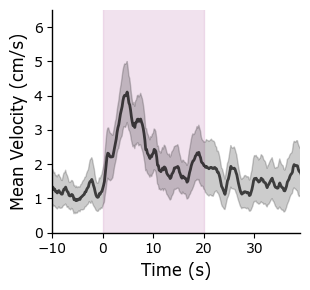

In [ ]:
plt.style.use('paper_style.mplstyle')
plt.figure(figsize=(3.2,3))
plt.fill_betweenx(y=[0, 6.6],  x1=0, x2=20,   color='#d3a0c8',  alpha=0.3)
sb.lineplot(data=downsampled_df,x='Time (s)',y='Mean Velocity (cm/s)',errorbar='se',color='k',alpha=.7)
plt.xlim([-10,39])
plt.ylim([0,6.5])
sb.despine()
plt.tight_layout()
plt.savefig("Fig5B_mean_velocity_tone_across_animal.svg",transparent=True,dpi=200)